Fitsファイルの中身を可視化するコード


# LASCO


https://lasco-www.nrl.navy.mil/lz/

## 初期設定・データファイルの可視化

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import os
# import fitsio
import numpy as np
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.optimize as opt
from scipy.special import beta
from scipy.ndimage import map_coordinates
from matplotlib.ticker import MultipleLocator, MaxNLocator, FormatStrFormatter, FuncFormatter, LogLocator, FixedLocator

# --- 定数 ---
sigma_cm2 = 6.6524587051e-25
Rsun_cm   = 6.95700e10
AU_cm     = 1.49597870700e13


# --- 読み込みたい .fts ファイルのパスを指定 ---
filename = os.path.expanduser('D:\wsl\home\kinno-7010\Research\SOHO\pB\C2-PB-20220613_0258.fts')

# --- ファイルをオープン ---
with fits.open(filename) as hdul:
    # FITS ファイル内の拡張ヘッダとデータ構造を一覧表示
    hdul.info()

    # プライマリヘッダを取得・表示
    header = hdul[0].header
    print("Primary Header:")
    print(repr(header))   # repr で改行入りに

    # もし拡張ヘッダが複数あれば、例えば1番目の拡張ヘッダも見る
    # ext_header = hdul[1].header
    # print("Extension Header [1]:", ext_header)

    # データ部を取得
    data = hdul[0].data
    print(f"\nData shape: {data.shape}")


<>:20: SyntaxWarning: invalid escape sequence '\w'
<>:20: SyntaxWarning: invalid escape sequence '\w'
C:\Users\touho\AppData\Local\Temp\ipykernel_18764\3881199804.py:20: SyntaxWarning: invalid escape sequence '\w'
  filename = os.path.expanduser('D:\wsl\home\kinno-7010\Research\SOHO\pB\C2-PB-20220613_0258.fts')


Filename: D:\wsl\home\kinno-7010\Research\SOHO\pB\C2-PB-20220613_0258.fts
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      54   (512, 512)   float32   
Primary Header:
SIMPLE  =                    T / Written by IDL:  Fri Jun 17 18:54:40 2022      
BITPIX  =                  -32 / Real*4 (floating point)                        
NAXIS   =                    2 /                                                
NAXIS1  =                  512 /                                                
NAXIS2  =                  512 /                                                
DATE-OBS= '2022-06-13T02:54:09.709' /                                           
DATE-END= '2022-06-13T03:03:34.398' /                                           
DATE-AVG= '2022-06-13T02:58:52.054' /                                           
TIME-OBS= '        '           /                                                
DATE    = '2022-06-17T22:54:40.332' /                

## 生データ(pBデータ)の可視化

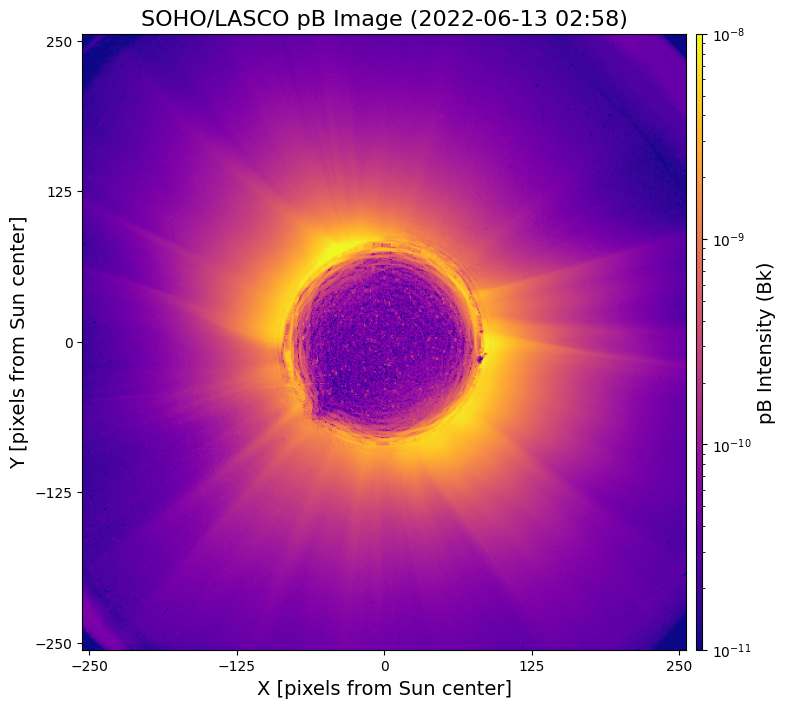

In [138]:


# --- your data ---
# data は 512×512 の 2D numpy 配列とします
h, w = data.shape  # 512, 512

# --- マスクの準備 ---
# プロット座標系では中心(0,0)になるように extent=[-w/2, w/2, -h/2, h/2] としているので、
# i,j ピクセル位置→座標への変換は以下の grid で OK
x = np.linspace(-w/2, w/2, w)
y = np.linspace(-h/2, h/2, h)
xx, yy = np.meshgrid(x, y)
r = np.sqrt(xx**2 + yy**2)

# 太陽半径何ピクセルか（ご自分のキャリブレーションに合わせてください）
pixels_per_Rsun = 45.0  
# ２ Rsun 以内をマスク
# mask = r <= (2 * pixels_per_Rsun)
# masked_data = np.ma.masked_where(mask, data)


# --- カラーマップをコピーしてマスク領域を灰色に設定 ---
cmap = plt.cm.plasma.copy()
cmap.set_bad(color='gray')

# --- プロット ---
fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    data,
    origin='lower',
    cmap=cmap,
    norm=LogNorm(vmin=1e-11, vmax=1e-8),
    aspect='auto',
    extent=[-w/2, w/2, -h/2, h/2]
)

# カラーバー
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('pB Intensity (Bk)', fontsize=14)

# 軸ラベル・タイトル
ax.set_xlabel('X [pixels from Sun center]', fontsize=14)
ax.set_ylabel('Y [pixels from Sun center]', fontsize=14)
ax.set_title('SOHO/LASCO pB Image (2022-06-13 02:58)', fontsize=16)

# 目盛り
ax.set_xticks([-250, -125, 0, 125, 250])
ax.set_yticks([-250, -125, 0, 125, 250])

plt.show()


In [79]:
masked_data

masked_array(
  data=[[4.607558692221181e-12, 1.1001212961436746e-11,
         1.524366743943517e-11, ..., 7.148337477502764e-12,
         7.3073673848012e-12, 6.299875118104259e-12],
        [1.6952301108014156e-12, 5.164694626830224e-12,
         4.194404372437344e-12, ..., 6.520270434684505e-12,
         5.974655232360293e-12, 4.110811517576973e-12],
        [1.1885268160274909e-12, 5.39501169433132e-12,
         5.014290198335214e-12, ..., 6.158049764559692e-12,
         5.195289944776027e-12, 6.611858630045653e-12],
        ...,
        [3.183648006679918e-13, 1.1487631592504988e-12,
         1.852731293036647e-12, ..., 6.26957795575589e-13,
         3.1612985341468447e-13, 2.081858990754526e-13],
        [5.560971062974762e-13, 1.4925071812124657e-12,
         1.706549940423685e-12, ..., 1.1949852728437155e-13,
         7.903572002594672e-13, 1.5491802719119763e-12],
        [2.772715867668807e-12, 3.1862140963817565e-12,
         1.3523851092808736e-12, ..., 1.3425739469816178e-

# 角度平均を採った密度データのプロット(2-6Rs)

## 初期設定・関数

In [6]:
import numpy as np
from pathlib import Path
from astropy.io import fits
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import curve_fit, fsolve
from scipy.integrate import trapezoid
from matplotlib.ticker import LogLocator, FuncFormatter
from scipy.optimize import root_scalar
from scipy.ndimage import map_coordinates
from matplotlib.colors import LogNorm

# --- 定数 ---
R_SUN = 6.96e10     # cm
sigma_T = 6.65e-25   # cm^2
u = 0.63
K_const = np.pi * sigma_T * (1 - u) / 6.0
_e = 1.60217662e-19     # C
_m_e = 9.10938356e-31   # kg
_eps0 = 8.854187817e-12   # F/m

# --- van de Hulst 型幾何重み関数 ---
def van_de_hulst_A(r):
    sinO = R_SUN/r
    cosO = np.sqrt(np.clip(1 - sinO**2, 0, 1))
    return cosO * sinO**2

def van_de_hulst_B(r):
    sinO = R_SUN/r
    cosO = np.sqrt(np.clip(1 - sinO**2, 0, 1))
    denom = np.where(np.abs(1 + 3*sinO**2) < 1e-12, 1e-12, 1 + 3*sinO**2)
    term1 = 1 - 3*sinO**2 - cosO**2
    logterm = np.log((1 + sinO) / np.clip(cosO, 1e-12, None))
    return -0.125 * (term1/denom) * sinO * logterm

def weight_pB(r_cm):
    return (1-u)*van_de_hulst_A(r_cm) + u*van_de_hulst_B(r_cm)

# べき乗の項が5つ（パラメータが10個）の関数
def triple_power(r, A1, p1, A2, p2, A3, p3, A4, p4, A5, p5):
    return A1*r**p1 + A2*r**p2 + A3*r**p3 + A4*r**p4 + A5*r**p5

def invert_ablation(pb_prof, r_mid, edges, n_bins):
    Ne = np.zeros_like(pb_prof)
    rho0 = r_mid[-1] * R_SUN
    tail_b = 3.0
    r_out = rho0 * 1.0001
    r_grid = np.linspace(r_out, 10*rho0, 2000)
    Wgrid = weight_pB(r_grid)
    geom = (rho0**2)/(r_grid * np.sqrt(r_grid**2-rho0**2))
    tail_factor = trapezoid(Wgrid * geom * (rho0/r_grid)**tail_b, r_grid)
    Ne[-1] = pb_prof[-1] / (K_const * tail_factor)
    for i in range(n_bins-2, -1, -1):
        rho = r_mid[i] * R_SUN
        pB_rem = pb_prof[i] / K_const
        for j in range(i+1, n_bins):
            if Ne[j] <= 0:
                continue
            r_in = max(edges[j], r_mid[i]) * R_SUN
            r_outj = edges[j+1] * R_SUN
            L_j = rho * (
                np.arctan(np.sqrt(r_outj**2-rho**2)/rho) -
                np.arctan(np.sqrt(max(r_in**2-rho**2,0))/rho)
            )
            Wj = weight_pB(r_mid[j]*R_SUN)
            pB_rem -= Wj * Ne[j] * L_j
        L_i = rho * np.arctan(np.sqrt((edges[i+1]*R_SUN)**2 - rho**2)/rho)
        Wi = weight_pB(r_mid[i]*R_SUN)
        Ne[i] = pB_rem / (Wi * L_i) if Wi*L_i>0 else 0.0
    return Ne


def density_from_frequency(freq_mhz):
    """
    freq_mhz [MHz] -> n_e [cm^-3]
    """
    f_hz_harmonic = freq_mhz * 1e6
    omega_p = 2 * np.pi * f_hz_harmonic
    ne_m3 = _eps0 * _m_e / _e**2 * omega_p**2
    return ne_m3 / 1e6     # cm^-3


def frequency_from_density(dens_cm3):
    """
    dens_cm3 [cm^-3] -> freq_mhz [MHz]
    """
    n_m3 = dens_cm3 * 1e6
    f_hz_harmonic = np.sqrt(n_m3 * _e**2 / (_eps0 * _m_e))
    return f_hz_harmonic / (2 * np.pi) / 1e6

def Saito1970(rho, phi: float=0):
    # initial_latitude = 21
    # rho += 1.0 # 太陽中心からに換算
    sin_phi = np.sin(np.radians(phi))
    return (3.09e8 * (rho) ** -16 * (1 - 0.5 * sin_phi) +
            1.58e8 * rho ** -6 * (1 - 0.95 * sin_phi) +
            0.0251e8 * rho ** -2.5 * (1 - np.sqrt(sin_phi)))

def Saito1977(rho):  # 2.5-5.5Rs
    C1 = [1.36e6, 5.27e4, 3.15e5]
    C2 = [1.68e8, 3.54e6, 1.60e6]
    d1 = [2.14, 3.30, 4.71]
    d2 = [6.13, 5.80, 3.01]
    
    background = C1[0]*rho**(-d1[0])+C2[0]*rho**(-d2[0])
    eq_hole = C1[1]*rho**(-d1[1])+C2[1]*rho**(-d2[1])
    pole_hole = C1[2]*rho**(-d1[2])+C2[2]*rho**(-d2[2])
    return background #, eq_hole, pole_hole


def Newkirk1961(rho):
    return 4.4e4*10**(4.32/rho)



_K = (1/(2*np.pi) *
      np.sqrt((1.60217662e-19)**2 /
              (8.854187817e-12 * 9.10938356e-31)) *
      1e3)                                     # ≈ 8.98×10³

def f_plasma(n_e_cm3: np.ndarray | float) -> np.ndarray | float:
    """Plasma frequency in **MHz** for a given electron density (cm⁻³)."""
    return _K * np.sqrt(n_e_cm3) / 1e6           # Hz → MHz

def rho_at_frequency(f_MHz: float,
                     model,
                     x0: float = 1.5) -> float:
    """
    Solve model(rho) that satisfies f_p(model(rho)) = f_MHz.
    """
    func = lambda r: f_plasma(model(r)) - f_MHz
    rho_solution, = fsolve(func, x0=float(x0), xtol=1e-10, maxfev=10000)
    return rho_solution

def find_rho_for_value(func, target, rho_min=1.0, rho_max=4.0):
    """
    func(rho) = 何らかの連続関数
    target      = その関数がとるべき値
    rho_min     = 探索開始点（下限）
    rho_max     = 探索終了点（上限）
    戻り値      = root_scalar で得られた rho の近似解
    """
    g = lambda rho: func(rho) - target
    sol = root_scalar(g, bracket=[rho_min, rho_max], method='brentq')
    if sol.converged:
        return sol.root
    else:
        raise RuntimeError("解の探索に失敗しました。範囲や関数の形を確認してください。")
    
def plot_ne_scatter_and_fit(ax,
                            r_fit_points, Ne_fit_points,           # Data used for the fit
                            r_curve_for_line, fit_params_tuple, theta_deg,
                            density_lower_highlight, density_upper_highlight): # Density bounds for highlighting
    """
    フィッティングデータ点（色分け）およびフィット曲線をプロットします。
    """
    # Fit label generation
    if len(fit_params_tuple) == 10:
        A1, p1, A2, p2, A3, p3, A4, p4, A5, p5 = fit_params_tuple
        fit_label_str = f'Fit: {A1:.2e}r$^{{{p1:.2f}}}$+{A2:.2e}r$^{{{p2:.2f}}}$+' \
                        f'{A3:.2e}r$^{{{p3:.2f}}}$+{A4:.2e}r$^{{{p4:.2f}}}$+' \
                        f'{A5:.2e}r$^{{{p5:.2f}}}$'
    else:
        fit_label_str = f"Fit (params: {len(fit_params_tuple)})"

    # # Plot the fit line
    # if len(r_curve_for_line) > 0 and len(fit_params_tuple) == 10:
    #     Ne_on_curve = triple_power(r_curve_for_line, *fit_params_tuple)
    #     ax.plot(r_curve_for_line, Ne_on_curve, '-', label=fit_label_str, linewidth=3, color='blue', zorder=1)

    # Categorize Ne_fit_points for plotting
    if len(r_fit_points) > 0 and len(Ne_fit_points) > 0 : # Ensure there are points
        # Ensure highlight bounds are valid numbers
        is_lower_valid = not np.isnan(density_lower_highlight)
        is_upper_valid = not np.isnan(density_upper_highlight)

        if is_lower_valid and is_upper_valid:
            mask_in_highlight_range = (Ne_fit_points >= density_lower_highlight) & \
                                      (Ne_fit_points <= density_upper_highlight)
        elif is_lower_valid: # Only lower bound is valid
             mask_in_highlight_range = (Ne_fit_points >= density_lower_highlight)
        elif is_upper_valid: # Only upper bound is valid
             mask_in_highlight_range = (Ne_fit_points <= density_upper_highlight)
        else: # Neither bound is valid, so no points are "in range" for highlighting
            mask_in_highlight_range = np.zeros_like(Ne_fit_points, dtype=bool)


        # Plot points in the highlight range (14-42 MHz) as red crosses
        if np.any(mask_in_highlight_range):
            ax.scatter(r_fit_points[mask_in_highlight_range], Ne_fit_points[mask_in_highlight_range],
                       s=60, c='red', marker='+', label=f'Fit Data (14-42 MHz, θ={theta_deg:.0f}°)')

        # Plot points outside the highlight range as cyan crosses
        if np.any(~mask_in_highlight_range):
            ax.scatter(r_fit_points[~mask_in_highlight_range], Ne_fit_points[~mask_in_highlight_range],
                       s=40, c='cyan', marker='x', label=f'Fit Data (Other, θ={theta_deg:.0f}°)')
    elif len(r_fit_points) > 0 : # No Ne_fit_points, but r_fit_points exist (unlikely)
         ax.scatter(r_fit_points, np.full_like(r_fit_points, np.nan), s=40, c='gray', marker='o', label="Fit Data (No Ne values)")

def find_r_from_density_local(target_density, r_search_range, fit_params):
    # この関数内で triple_power が利用可能であること
    r_values_search = np.linspace(r_search_range[0], r_search_range[1], 2000) # 解像度を上げる
    densities_on_curve = triple_power(r_values_search, *fit_params)
    idx = np.argmin(np.abs(densities_on_curve - target_density))
    # ターゲット密度に最も近い密度が、カーブ上に実際に存在するか簡単なチェック
    if np.abs(densities_on_curve[idx] - target_density) > target_density * 0.5: # 差が大きい場合はNaNを返すなど
        print(f"Warning: Could not find a good match for target_density {target_density:.2e}")
    #     return np.nan
    return r_values_search[idx]

def plot_frequency_radii(ax, r_plot_max, fit_params_tuple, density_plot_min):
    """
    特定のプラズマ周波数に対応する半径を計算し、縦線とテキストでプロットします。
    """


    # この関数内で density_from_frequency が利用可能であること
    ne_14MHz = density_from_frequency(14)
    ne_42MHz = density_from_frequency(42)

    r_14MHz = find_r_from_density_local(ne_14MHz, (1.0, r_plot_max), fit_params_tuple)
    r_42MHz = find_r_from_density_local(ne_42MHz, (1.0, r_plot_max), fit_params_tuple)

    print(f"14MHz (Ne={ne_14MHz:.2e} cm^-3) に対応する r = {r_14MHz:.2f} R_sun")
    print(f"42MHz (Ne={ne_42MHz:.2e} cm^-3) に対応する r = {r_42MHz:.2f} R_sun")

    # if not np.isnan(r_14MHz):
    #     ax.vlines(r_14MHz, density_plot_min, ne_14MHz, color='black', linestyle=':', lw=1.5)
    #     ax.text(r_14MHz, density_plot_min, f'{r_14MHz:.2f}', ha='center', va='top', color='black', fontsize=12, rotation=90) # テキスト調整
    # if not np.isnan(r_42MHz):
    #     ax.vlines(r_42MHz, density_plot_min, ne_42MHz, color='black', linestyle=':', lw=1.5)
    #     ax.text(r_42MHz, density_plot_min, f'{r_42MHz:.2f}', ha='center', va='top', color='black', fontsize=12, rotation=90) # テキスト調整
        
    # ax.vlines(1.1, density_plot_min, )

def plot_reference_density_models(ax, r_curve, model_multipliers):
    """
    参照密度モデル（Newkirk, Saitoなど）をプロットします。
    model_multipliers: {'Newkirk_C': const1, 'Saito1970_C': const2, ...}
    """
    # この関数内で Newkirk1961, Saito1970, Saito1977 が利用可能であること
    nc = model_multipliers.get('Newkirk_C', 1)
    s70c = model_multipliers.get('Saito1970_C', 5.3)
    s77c = model_multipliers.get('Saito1977_C', 4.9)
    
    ax.plot(r_curve, nc * Newkirk1961(r_curve), 
            label=f'{nc} fold Newkirk 1961', linestyle='--', linewidth=2)
    ax.plot(r_curve, s70c * Saito1970(r_curve, phi=0), # phi=0 は例
            label=f'{s70c} fold Saito 1970 (eq.)', linestyle='--', linewidth=2) # 'eq.' for phi=0
    ax.plot(r_curve, s77c * Saito1977(r_curve), 
            label=f'{s77c} fold Saito+ 1977', linestyle='--', linewidth=2)

def plot_hf_antenna_band(ax, r_plot_max):
    """
    HFアンテナの周波数帯に対応する密度範囲を水平スパンでプロットします。
    """
    # この関数内で density_from_frequency が利用可能であること
    ne_14MHz = density_from_frequency(14)
    ne_42MHz = density_from_frequency(42)

    ax.axhspan(ne_14MHz, ne_42MHz, color='gray', alpha=0.15, # alpha値を少し調整
               label='HF antenna (14–42 MHz)')
    ax.text(r_plot_max, ne_14MHz, '14 MHz', va='bottom', ha='right', fontsize=12, color='dimgray') # テキスト調整
    ax.text(r_plot_max, ne_42MHz, '42 MHz', va='top', ha='right', fontsize=12, color='dimgray')      # テキスト調整

def setup_ne_plot_axes_and_legend(ax, x_limits, y_limits, title):
    """
    電子密度プロットの主軸のスケール、範囲、ラベル、タイトル、グリッド、凡例を設定します。
    """
    ax.set_yscale('log')
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.set_xlabel('r [R$_\\odot$]', fontsize=16)
    ax.set_ylabel('N$_e$ [cm$^{-3}$]', fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(which='both', ls='--', alpha=0.7) # alpha値を少し調整
    ax.set_title(title, fontsize=18)
    ax.legend(fontsize=11, loc='upper right') # locを指定、fontsize調整

def add_frequency_secondary_axis(ax):
    """
    電子密度プロットに周波数の第2Y軸を追加します。
    """
    # この関数内で frequency_from_density, density_from_frequency, LogLocator, FuncFormatter が利用可能であること
    secax = ax.secondary_yaxis(
        'right',
        functions=(frequency_from_density, density_from_frequency)
    )
    secax.set_ylabel('Plasma Frequency [MHz]', fontsize=16) # ラベル修正
    secax.set_yscale('log') # 対数スケールを明示
    
    # 目盛りとフォーマッタを適切に設定 (必要に応じて調整)
    # 例: 主要な周波数 (1, 10, 100 MHzなど) に目盛りを打ちたい場合
    secax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0, 2.0, 5.0))) # 1,2,5,10,20,50,...
    secax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}" if x >=1 else f"{x:.1f}")) # 整数の場合は.0なし、小数は.1f
    secax.tick_params(axis='y', which='major', labelsize=14) # labelsizeを primary と合わせる


# --- Main plotting function for Ne profile ---

def generate_ne_profile_plot(ax,
                              r_fit_data_points, Ne_fit_data_points,
                              # r_highlight_data, Ne_highlight_data, # These are removed
                              fit_params_tuple,
                              plot_r_min, plot_r_max, # These will now correctly receive floats
                              theta_deg_val,
                              density_plot_limits,
                              model_multipliers_dict,
                              # New arguments for density bounds for plot_ne_scatter_and_fit
                              density_lower_highlight_bound, density_upper_highlight_bound):
    """
    指定された軸 (ax) に電子密度プロファイルと関連情報を描画します。
    """
    if plot_r_min is None or plot_r_max is None or plot_r_min >= plot_r_max : # plot_r_min/max are now floats
        r_curve_for_line_drawing = np.array([plot_r_min]) if plot_r_min is not None else np.array([])
    else:
        r_curve_for_line_drawing = np.linspace(plot_r_min, plot_r_max, 500)

    # Pass density bounds to plot_ne_scatter_and_fit for conditional coloring
    plot_ne_scatter_and_fit(ax, r_fit_data_points, Ne_fit_data_points,
                            r_curve_for_line_drawing, fit_params_tuple, theta_deg_val,
                            density_lower_highlight_bound, density_upper_highlight_bound) # Pass bounds
    
    density_min_for_plot, _ = density_plot_limits # density_max_for_plot not used directly here
    
    if len(fit_params_tuple) == 10: # Assuming 5-term power law
        plot_frequency_radii(ax, plot_r_max, fit_params_tuple, density_min_for_plot)
        plot_reference_density_models(ax, r_curve_for_line_drawing, model_multipliers_dict)
    # else:
        # print(f"Skipping frequency radii and reference models due to param count: {len(fit_params_tuple)}")

    plot_hf_antenna_band(ax, plot_r_max)
    title = f'Electron Density Profile (θ={theta_deg_val:.0f}°)'
    # setup_ne_plot_axes_and_legend will draw the legend based on what's plotted
    setup_ne_plot_axes_and_legend(ax, (plot_r_min, plot_r_max), density_plot_limits, title)
    add_frequency_secondary_axis(ax)
# --- ファイルパス定義 ---
# Windows上でのWSLパスを使用していると仮定します。通常のWindowsパスやLinuxパスも同様に指定可能です。
filename_mk4 = r'D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\pB\20220613_025810_kcor_l2.fts'
filename_lasco = r'D:\wsl\home\kinno-7010\Research\SOHO\pB\C2-PB-20220613_0258.fts'


def load_and_prepare_instrument_data(filename, instrument_name, is_lasco=False):
    """
    FITSファイルを読み込み、観測機器の基本パラメータを抽出・計算します。
    """
    try:
        with fits.open(filename) as hdul:
            data = hdul[0].data.astype(float)
            header = hdul[0].header
            print(f"Successfully loaded {instrument_name} file: {filename}")
    except FileNotFoundError:
        print(f"CRITICAL Error: {instrument_name} file '{filename}' not found. Please check the path.")
        exit()
    except Exception as e:
        print(f"CRITICAL Error: Could not read {instrument_name} file '{filename}'. Error: {e}")
        exit()

    params = {}
    try:
        params['nx'] = header['NAXIS1']
        params['ny'] = header['NAXIS2']
        params['cx'] = header['CRPIX1'] - 1
        params['cy'] = header['CRPIX2'] - 1
        params['scale'] = abs(header['CDELT1'])

        if is_lasco:
            # SOHO/LASCO: RSUN_OBS がヘッダーにない場合があるためデフォルト値を使用
            params['rsun_arc'] = header.get('RSUN_OBS', 959.2)
            if 'RSUN_OBS' not in header:
                print(f"Warning: {instrument_name} 'RSUN_OBS' not found in header. Using default value: {params['rsun_arc']} arcsec.")
        else: # Mk4
            if 'RSUN_OBS' in header:
                params['rsun_arc'] = header['RSUN_OBS']
            elif 'R_SUN' in header and 'CDELT1' in header: # フォールバック
                params['rsun_arc'] = header['R_SUN'] * abs(header['CDELT1'])
                print(f"Warning: {instrument_name} 'RSUN_OBS' not found, calculated from 'R_SUN' and 'CDELT1'.")
            else:
                raise KeyError(f"{instrument_name} header missing solar radius information (RSUN_OBS or R_SUN/CDELT1).")
        
        params['px_per_rsun'] = params['rsun_arc'] / params['scale']
        
        print(f"{instrument_name} params: cx={params['cx']:.2f}, cy={params['cy']:.2f}, "
              f"scale={params['scale']:.3f} arcsec/px, rsun={params['rsun_arc']:.2f} arcsec, "
              f"R_sun_px={params['px_per_rsun']:.2f} px")
        
    except KeyError as e:
        print(f"CRITICAL Error: Missing essential keyword in {instrument_name} header: {e}. Cannot proceed.")
        exit()
        
    return data, params

def combine_corona_data(data_lasco, params_lasco, data_mk4, params_mk4, r_map_lasco, r_ranges):
    """
    Mk4データをLASCOグリッドに補間し、指定範囲に基づいて両データを統合します。
    """
    # LASCOグリッドにおける正規化座標
    y_l_idx, x_l_idx = np.indices((params_lasco['ny'], params_lasco['nx']))
    x_norm_on_lasco_grid = (x_l_idx - params_lasco['cx']) / params_lasco['px_per_rsun']
    y_norm_on_lasco_grid = (y_l_idx - params_lasco['cy']) / params_lasco['px_per_rsun']

    # Mk4データサンプリング用の座標を計算
    coords_for_mk4_sampling_y = y_norm_on_lasco_grid * params_mk4['px_per_rsun'] + params_mk4['cy']
    coords_for_mk4_sampling_x = x_norm_on_lasco_grid * params_mk4['px_per_rsun'] + params_mk4['cx']
    
    coords_mk4_sampling = np.vstack([coords_for_mk4_sampling_y.ravel(),
                                      coords_for_mk4_sampling_x.ravel()])

    interp_mk4_on_lasco_grid = map_coordinates(data_mk4, coords_mk4_sampling,
                                               order=1, mode='constant', cval=np.nan)
    interp_mk4_on_lasco_grid = interp_mk4_on_lasco_grid.reshape((params_lasco['ny'], params_lasco['nx']))

    # 統合画像の作成
    final_image = np.full_like(data_lasco, np.nan)

    mask_lasco_region = (r_map_lasco >= r_ranges['mk4_outer_lasco_inner']) & \
                        (r_map_lasco <= r_ranges['lasco_outer'])
    final_image[mask_lasco_region] = data_lasco[mask_lasco_region]

    mask_mk4_region = (r_map_lasco >= r_ranges['mk4_inner']) & \
                      (r_map_lasco < r_ranges['mk4_outer_lasco_inner'])
    final_image[mask_mk4_region] = interp_mk4_on_lasco_grid[mask_mk4_region]

    # 指定範囲外を NaN でマスク
    final_image[r_map_lasco < r_ranges['mk4_inner']] = np.nan
    final_image[r_map_lasco > r_ranges['lasco_outer']] = np.nan
    
    return final_image

def plot_combined_image(image_data, r_map_plot, params_lasco, r_ranges, theta_deg_overlay=None): # theta_deg_overlay を追加
    """
    統合されたコロナ画像をプロットします。指定された角度に線を描画する機能を含みます。
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    extent_pixels = [-params_lasco['cx'], params_lasco['nx'] - params_lasco['cx'],
                     -params_lasco['cy'], params_lasco['ny'] - params_lasco['cy']]

    valid_data = image_data[~np.isnan(image_data) & (image_data > 0)]
    plot_vmin = np.min(valid_data) if len(valid_data) > 0 else 1e-11
    plot_vmax = np.max(valid_data) if len(valid_data) > 0 else 1e-6
    if plot_vmin <= 0: plot_vmin = 1e-12
    if plot_vmax <= plot_vmin: plot_vmax = plot_vmin * 1000

    cmap = plt.cm.plasma.copy()
    cmap.set_bad(color='lightgray')

    im = ax.imshow(image_data, origin='lower', cmap=cmap,
                   norm=LogNorm(vmin=plot_vmin, vmax=plot_vmax),
                   extent=extent_pixels, aspect='equal')

    # 等高線 (整数 R_sun)
    int_levels = np.arange(1, int(np.floor(r_ranges['lasco_outer'])) + 1)
    ax.contour(r_map_plot, levels=int_levels, colors='white', linewidths=1,
               linestyles='--', extent=extent_pixels, alpha=0.7) # alpha追加

    # 境界線と凡例の準備
    boundary_lines_for_legend = [] 
    
    legend_info = {
        r_ranges['mk4_inner']: (f"{r_ranges['mk4_inner']:.1f} $R_\\odot$ (Mk4 inner)", 'magenta'),
        r_ranges['mk4_outer_lasco_inner']: (f"{r_ranges['mk4_outer_lasco_inner']:.1f} $R_\\odot$ (Mk4/LASCO)", 'green'),
        r_ranges['lasco_outer']: (f"{r_ranges['lasco_outer']:.1f} $R_\\odot$ (LASCO outer)", 'blue')
    }
    sorted_levels_for_legend = sorted(legend_info.keys())

    for level_val in sorted_levels_for_legend:
        label_text, color = legend_info[level_val]
        if level_val <= np.nanmax(r_map_plot) and level_val >= np.nanmin(r_map_plot):
            ax.contour(r_map_plot, levels=[level_val],
                       colors=[color],
                       linewidths=1.2, linestyles='-.', extent=extent_pixels)
            proxy_line = plt.Line2D([0], [0], linestyle='-.', color=color, linewidth=1.2, label=label_text)
            boundary_lines_for_legend.append(proxy_line)

    ax.plot(0, 0, '+', color='black', markersize=12, markeredgewidth=1.5) # マーカーサイズ調整

    # --- ここから θ方向の線を描画 ---
    if theta_deg_overlay is not None:
        theta_rad_overlay = np.radians(theta_deg_overlay)
        # 線の描画範囲 (Rsun 単位)
        # プロット範囲全体に線を引くために、少し外側から始めることもできます
        # ここでは、表示されているコロナデータの範囲に合わせます
        r_line_min_rsun = 0 # 中心から描画開始
        r_line_max_rsun = r_ranges['lasco_outer'] # 少し外側まで線を伸ばす

        r_coords_rsun = np.array([r_line_min_rsun, r_line_max_rsun]) # 始点と終点のみで直線を定義
        
        # Rsun から LASCO グリッド上のピクセル座標へ変換
        # (0,0) が太陽中心なので、そのままプロット可能
        x_overlay_pix = r_coords_rsun * params_lasco['px_per_rsun'] * np.cos(theta_rad_overlay)
        y_overlay_pix = r_coords_rsun * params_lasco['px_per_rsun'] * np.sin(theta_rad_overlay)
        
        # 線を描画し、凡例のためのアーティストを取得
        line_artist_theta, = ax.plot(x_overlay_pix, y_overlay_pix, 
                                      color='cyan', linestyle='-', linewidth=2, 
                                      label=f'θ={theta_deg_overlay:.0f}°')
        boundary_lines_for_legend.append(line_artist_theta) # 凡例リストに追加
    # --- θ方向の線の描画ここまで ---

    # カラーバーとラベル
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="1%", pad=0.1) # サイズを3%に調整
    cb = plt.colorbar(im, cax=cax, label='pB [B$_\\odot$]')
    cb.ax.tick_params(labelsize=12) # ラベルサイズ調整

    ax.set_title(f"Combined Mk4 & LASCO pB ({r_ranges['mk4_inner']:.1f}–{r_ranges['lasco_outer']:.1f} $R_\\odot$)", fontsize=18) # タイトル簡略化 & サイズ調整
    
    if boundary_lines_for_legend:
        ax.legend(handles=boundary_lines_for_legend, loc='upper right', fontsize=10) # 位置とフォントサイズ調整

    # ax.set_xlabel('X [pixels from Sun center, LASCO grid]', fontsize=14) # フォントサイズ調整
    # ax.set_ylabel('Y [pixels from Sun center, LASCO grid]', fontsize=14) # フォントサイズ調整
    ax.tick_params(axis='both', which='major', labelsize=12) # 目盛りラベルサイズ調整
    
    plt.tight_layout()

# --- プロファイル抽出関数 (新しいバージョン) ---
def extract_pB_profile(image_data_extract, r_map_extract, theta_deg_extract, r_bins_extract, 
                       cy_center, cx_center, ny_grid, nx_grid): # Added center and grid size params
    theta_rad_extract = np.radians(theta_deg_extract)
    angle_tolerance_rad = np.radians(5)
    
    # Define y_idx, x_idx based on the grid of image_data_extract
    y_idx_grid, x_idx_grid = np.indices((ny_grid, nx_grid))

    angle_map_extract = np.arctan2(y_idx_grid - cy_center, x_idx_grid - cx_center)
    angle_diff = np.arctan2(np.sin(angle_map_extract - theta_rad_extract), np.cos(angle_map_extract - theta_rad_extract))
    
    mask_angle = (np.abs(angle_diff) < angle_tolerance_rad)
    mask_valid_pb = (~np.isnan(image_data_extract)) & (image_data_extract > 0) # Ensure pB is positive for physical sense
    
    combined_mask = mask_angle & mask_valid_pb
    
    pB_profile_extracted = np.zeros(len(r_bins_extract) - 1)
    
    for i in range(len(r_bins_extract) - 1):
        r_min_bin = r_bins_extract[i]
        r_max_bin = r_bins_extract[i+1]
        
        bin_mask_radius = (r_map_extract >= r_min_bin) & (r_map_extract < r_max_bin)
        final_bin_mask = bin_mask_radius & combined_mask
        
        if np.any(final_bin_mask):
            pB_profile_extracted[i] = np.nanmean(image_data_extract[final_bin_mask])
        else:
            pB_profile_extracted[i] = np.nan
            
    return pB_profile_extracted


## 密度モデル

### plot


In [49]:


# --- 1) FITS 読み込み & プロファイル抽出 ---
# filename = str(Path.home()/'Research'/'SOHO'/'pB'/'C2-PB-20220613_0258.fts')
with fits.open(filename) as hdul:
    pb_data = hdul[0].data.astype(float)
    hdr     = hdul[0].header

cx = hdr['CRPIX1']-1;  cy = hdr['CRPIX2']-1
arcsec_per_px   = abs(hdr['CDELT1'])
solar_radius_as = hdr.get('RSUN_OBS', 959.2)
px_per_Rsun     = solar_radius_as/arcsec_per_px

ny, nx = pb_data.shape
y, x   = np.indices((ny,nx))
r_map  = np.hypot((x-cx)/px_per_Rsun, (y-cy)/px_per_Rsun)

# --- 2.2–9.0 R⊙ のビン & pB プロファイル ---
r_min, r_max, dr = 2.2, 9.0, 0.01
edges = np.arange(r_min, r_max+dr, dr)
r_mid  = 0.5*(edges[:-1]+edges[1:])
n_bins = len(r_mid)


pb_profile = np.zeros(n_bins)
for i in range(n_bins):
    mask = (r_map >= edges[i]) & (r_map < edges[i+1])
    vals = pb_data[mask]
    vals = vals[np.isfinite(vals)]
    pb_profile[i] = np.mean(vals) if vals.size else 0.0

# --- 3) Onion-peeling Abel 反転で Ne(r_mid) 計算 ---
Ne_profile = np.zeros(n_bins)
rho0        = r_mid[-1] * R_SUN
tail_b      = 3.0
r_out       = rho0 * 1.0001
r_grid      = np.linspace(r_out, 10*rho0, 2000)
Wgrid       = weight_pB(r_grid)
geom        = (rho0**2) / (r_grid * np.sqrt(r_grid**2 - rho0**2))
tail_factor = np.trapezoid(Wgrid * geom * (rho0/r_grid)**tail_b, r_grid)
Ne_profile[-1] = pb_profile[-1] / (K_const * tail_factor)

for i in range(n_bins-2, -1, -1):
    rho    = r_mid[i] * R_SUN
    pB_rem = pb_profile[i] / K_const
    for j in range(i+1, n_bins):
        if Ne_profile[j] <= 0: 
            continue
        r_in   = max(edges[j], r_mid[i]) * R_SUN
        r_outj = edges[j+1] * R_SUN
        L_j    = rho * (
            np.arctan(np.sqrt(r_outj**2 - rho**2)/rho) -
            np.arctan(np.sqrt(max(r_in**2 - rho**2,0))/rho)
        )
        Wj     = weight_pB(r_mid[j]*R_SUN)
        pB_rem -= Wj * Ne_profile[j] * L_j
    r_out_i      = edges[i+1] * R_SUN
    L_i          = rho * np.arctan(np.sqrt(r_out_i**2 - rho**2)/rho)
    Wi           = weight_pB(r_mid[i]*R_SUN)
    Ne_profile[i] = pB_rem / (Wi * L_i) if Wi*L_i > 0 else 0.0

# --- 4) R>8 を NaN にして可視化用配列作成 ---
Ne_plot = Ne_profile.copy()
Ne_plot[r_mid > r_max] = np.nan

# --- 5) フィッティング範囲のマスク (2.2–8.0) ---
mask_fit = (r_mid >= r_min) & (r_mid <= 8) & np.isfinite(Ne_profile)
r_data  = r_mid[mask_fit]
Ne_data = Ne_profile[mask_fit]


# --- 5.5) 3σ外れ値の除去 ---
# mask_base は従来どおり
mask_base = (
    (r_mid >= r_min) &
    (r_mid <= r_max) &
    np.isfinite(Ne_profile)
)
r0  = r_mid[mask_base]
Ne0 = Ne_profile[mask_base]
# 対数に変換
logNe = np.log10(Ne0)
# 対数空間で平均・標準偏差
mu_log   = np.nanmean(logNe)
sigma_log= np.nanstd(logNe)

# log-space で 3σ クリップ
mask_log = np.abs(logNe - mu_log) <= 3*sigma_log

# フィット用データ
r_fit_data = r0[mask_log]
Ne_fit_data = Ne0[mask_log]

# 初期推定値
p0 = [1.5e7, -3.4, 2.6e7, -3.4, 2.6e7, -3.4]

params, cov = curve_fit(triple_power, r_fit_data, Ne_fit_data,
                        p0=p0, maxfev=100000)
A1, p1, A2, p2, A3, p3 = params

print("Triple-power fit results:")
print(f" A1={A1:.2e}, p1={p1:.2f}")
print(f" A2={A2:.2e}, p2={p2:.2f}")
print(f" A3={A3:.2e}, p3={p3:.2f}")

# --- 7) 結果プロット ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

# (a) pB マスク画像
plot_pb = pb_data.copy()
plot_pb[(r_map < r_min) | (r_map > r_max-1)] = np.nan
xmin, xmax = -cx, nx - cx
ymin, ymax = -cy, ny - cy
im = ax1.imshow(np.log10(plot_pb), origin='lower', cmap='plasma',
                vmin=-11, vmax=-8,
                extent=[xmin,xmax,ymin,ymax], aspect='equal')

# 元の r_min, r_max の輪郭
ax1.contour(r_map, levels=[r_min, r_max-1], colors='black', linewidths=2,
            extent=[xmin,xmax,ymin,ymax])

# 追加：整数 R_s 位置の点線円
int_levels = np.arange(1, int(np.floor(r_max-1)) + 1)  # 1,2,3,... up限まで
ax1.contour(r_map, levels=int_levels, colors='white', linewidths=0.8,
            linestyles='--', extent=[xmin,xmax,ymin,ymax], alpha=0.7)

cax = make_axes_locatable(ax1).append_axes("right", size="1%", pad=0.05)
cb  = fig.colorbar(im, cax=cax)
cb.set_label('log10 pB [B$_\odot$]', fontsize=16)
ax1.set_xlabel('X [pix]', fontsize=16); ax1.set_ylabel('Y [pix]', fontsize=16)
ax1.set_title(f'LASCO-C2 pB data (2022-06-13 02:58 UT; {r_min:.1f}–{r_max-1:.1f} R$_\\odot$)', fontsize=16)
ax1.plot((xmax+xmin)/2, (ymax+ymin)/2, '+', color='black', markersize=12)

# (b) Ne プロファイル + 3-term フィット
ax2.scatter(r_mid, Ne_plot, s=10, color='lightgray', label='Data')
ax2.scatter(r_fit_data, Ne_fit_data, s=30, color='pink', marker='x', label='Fit range')

r_curve = np.linspace(1.0, r_max+1, 500)
ax2.plot(r_curve, triple_power(r_curve, *params),
         '-', label=f'Fit: {A1:.2e} r^({p1:.2f}) + {A2:.2e} r^({p2:.2f}) + {A3:.2e} r^({p3:.2f})', linewidth=5)

Newkirk_C = 0.8
Saito1970_C = 40
Saito1977_C = 4

ax2.plot(r_curve, Newkirk_C * Newkirk1961(r_curve), label=f'{Newkirk_C} fold Newkirk 1961', linestyle='--', linewidth=2)
ax2.plot(r_curve, Saito1970_C * Saito1970(r_curve, phi=0), label=f'{Saito1970_C} fold Saito 1970 (phi=0)', linestyle='--', linewidth=2)
ax2.plot(r_curve, Saito1977_C * Saito1977(r_curve), label=f'{Saito1977_C} fold Saito+ 1977', linestyle='--', linewidth=2)

ax2.axhspan(density_from_frequency(14), density_from_frequency(42), color='gray', alpha=0.2,
           label='HF antenna (14–42 MHz)')
ax2.text(r_max-1, density_from_frequency(14), '14', va='bottom', ha='left', fontsize=14, color='gray')
ax2.text(r_max-1, density_from_frequency(42), '42', va='top', ha='left', fontsize=14, color='gray')


ax2.set_yscale('log')
ax2.set_xlim(1.0, r_max-1)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_xlabel('r [R$_\\odot$]', fontsize=16)
ax2.set_ylabel('N$_e$ [cm$^{-3}$]', fontsize=16)
ax2.set_title('Ne(r) profile and density model fit', fontsize=16)
ax2.grid(True, which='both', ls='--')
ax2.legend(loc='best')

secax = ax2.secondary_yaxis(
        'right',
        functions=(frequency_from_density, density_from_frequency)
    )
secax.set_ylabel('Frequency [MHz]', fontsize=16)
secax.set_yscale('log')
secax.yaxis.set_major_locator(LogLocator(base=10))
secax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))
secax.tick_params(axis='both', which='major', labelsize=14)


plt.tight_layout()
plt.show()

<>:127: SyntaxWarning: invalid escape sequence '\o'
<>:127: SyntaxWarning: invalid escape sequence '\o'
C:\Users\touho\AppData\Local\Temp\ipykernel_7288\1597376018.py:127: SyntaxWarning: invalid escape sequence '\o'
  cb.set_label('log10 pB [B$_\odot$]', fontsize=16)
C:\Users\touho\AppData\Local\Temp\ipykernel_7288\1597376018.py:80: RuntimeWarning: invalid value encountered in log10
  logNe = np.log10(Ne0)
C:\Users\touho\AppData\Local\Temp\ipykernel_7288\1597376018.py:127: SyntaxWarning: invalid escape sequence '\o'
  cb.set_label('log10 pB [B$_\odot$]', fontsize=16)


TypeError: triple_power() missing 4 required positional arguments: 'A4', 'p4', 'A5', and 'p5'

All averaged data fit results:
 A1=1.98e+07, p1=-3.29
 A2=1.42e+07, p2=-3.29
 A3=2.39e+07, p3=-3.29
⚠️ θ=150° 線上データにフィット可能な点がありません


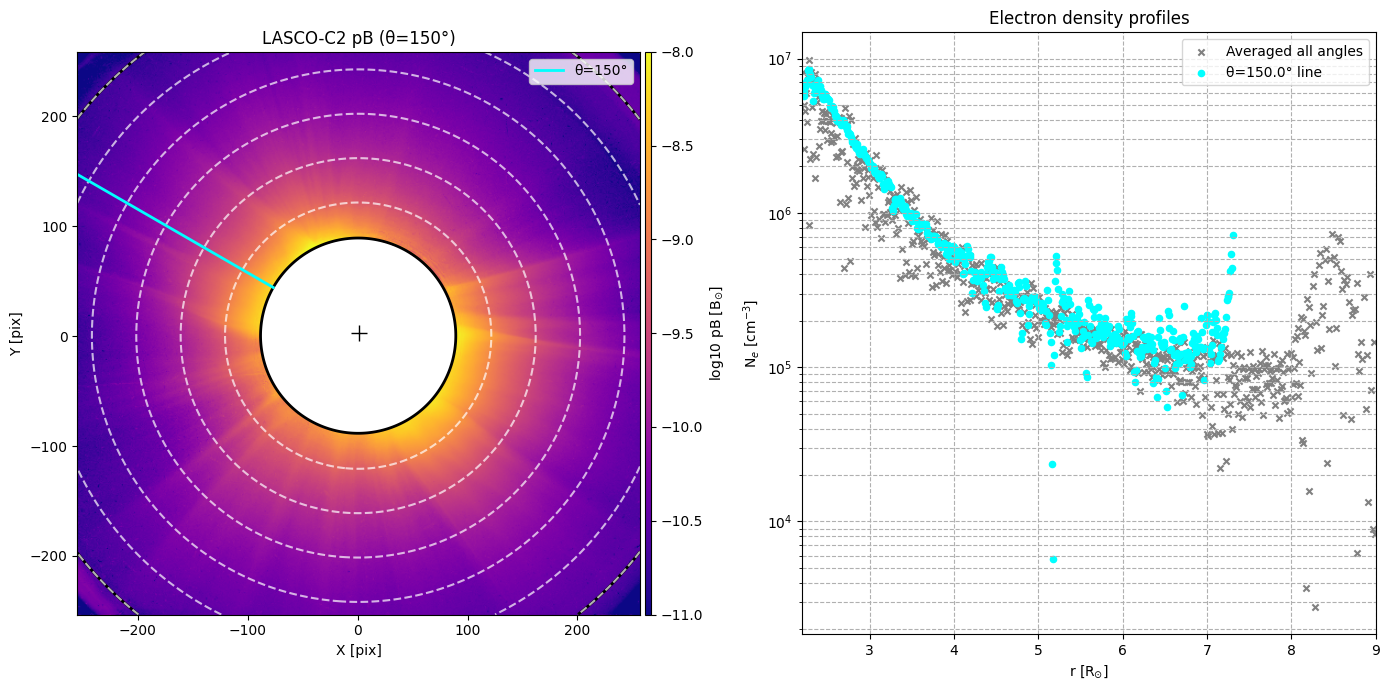

In [4]:
import numpy as np
from pathlib import Path
from astropy.io import fits
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import map_coordinates
from scipy.optimize import curve_fit

# --- （省略）Saito1970, Saito1977, Newkirk1961, f_plasma, rho_at_frequency,
#     triple_power, weight_pB, _K, K_const, R_SUN の定義は元コードのまま ---

# --- 1) FITS 読み込み & プロファイル抽出 ---
# filename = str(Path.home()/'Research'/'SOHO'/'pB'/'C2-PB-20220613_0258.fts')
with fits.open(filename) as hdul:
    pb_data = hdul[0].data.astype(float)
    hdr     = hdul[0].header

cx = hdr['CRPIX1']-1; cy = hdr['CRPIX2']-1
arcsec_per_px   = abs(hdr['CDELT1'])
solar_radius_as = hdr.get('RSUN_OBS', 959.2)
px_per_Rsun     = solar_radius_as/arcsec_per_px

ny, nx = pb_data.shape
y, x   = np.indices((ny,nx))
r_map  = np.hypot((x-cx)/px_per_Rsun, (y-cy)/px_per_Rsun)

# --- 2) 2.2–9.0 R⊙ のビン & pB プロファイル ---
r_min, r_max, dr = 2.2, 9.0, 0.01
edges = np.arange(r_min, r_max+dr, dr)
r_mid = 0.5*(edges[:-1]+edges[1:])
n_bins = len(r_mid)

pb_all = np.zeros(n_bins)
for i in range(n_bins):
    mask = (r_map >= edges[i]) & (r_map < edges[i+1])
    vals = pb_data[mask]
    vals = vals[np.isfinite(vals)]
    pb_all[i] = np.mean(vals) if vals.size else 0.0

# --- 3) Onion-peeling Abel 反転で Ne(r_mid) 計算準備 ---
Ne_all  = np.zeros(n_bins)
Ne_line = np.zeros(n_bins)

rho0   = r_mid[-1] * R_SUN
tail_b = 3.0
r_out  = rho0 * 1.0001
r_grid = np.linspace(r_out, 10*rho0, 2000)
Wgrid  = weight_pB(r_grid)
geom   = (rho0**2)/(r_grid*np.sqrt(r_grid**2 - rho0**2))
tail_factor = np.trapezoid(Wgrid * geom * (rho0/r_grid)**tail_b, r_grid)

Ne_all[-1]  = pb_all[-1]  / (K_const * tail_factor)

# --- 4) θ=150° の線上 pB プロファイル抽出 & 反転初期化 ---
theta_deg = 150.0
theta_rad = np.radians(theta_deg)
x_line = cx + r_mid*px_per_Rsun * np.cos(theta_rad)
y_line = cy + r_mid*px_per_Rsun * np.sin(theta_rad)
coords = np.vstack([y_line, x_line])
pb_line = map_coordinates(pb_data, coords, order=1, mode='constant', cval=np.nan)

Ne_line[-1] = pb_line[-1] / (K_const * tail_factor)

# --- 葉切り法反転ループ ---
for i in range(n_bins-2, -1, -1):
    rho = r_mid[i] * R_SUN
    pB_rem_all  = pb_all[i]  / K_const
    pB_rem_line = pb_line[i] / K_const

    for j in range(i+1, n_bins):
        if Ne_all[j]  > 0:
            r_in  = max(edges[j],    r_mid[i])   * R_SUN
            r_outj= edges[j+1]       * R_SUN
            L_j   = rho * (
                np.arctan(np.sqrt(r_outj**2 - rho**2)/rho) -
                np.arctan(np.sqrt(max(r_in**2 - rho**2,0))/rho)
            )
            Wj    = weight_pB(r_mid[j]*R_SUN)
            pB_rem_all  -= Wj * Ne_all[j]  * L_j

        if Ne_line[j] > 0:
            r_in  = max(edges[j],    r_mid[i])   * R_SUN
            r_outj= edges[j+1]       * R_SUN
            L_j   = rho * (
                np.arctan(np.sqrt(r_outj**2 - rho**2)/rho) -
                np.arctan(np.sqrt(max(r_in**2 - rho**2,0))/rho)
            )
            Wj    = weight_pB(r_mid[j]*R_SUN)
            pB_rem_line -= Wj * Ne_line[j] * L_j

    L_i     = rho * np.arctan(np.sqrt((edges[i+1]*R_SUN)**2 - rho**2)/rho)
    Wi      = weight_pB(r_mid[i]*R_SUN)
    Ne_all[i]  = pB_rem_all  / (Wi*L_i) if Wi*L_i > 0 else 0.0
    Ne_line[i] = pB_rem_line / (Wi*L_i) if Wi*L_i > 0 else 0.0

# --- 5) R>9 R⊙ を NaN に ---
Ne_all[r_mid > r_max]  = np.nan
Ne_line[r_mid > r_max] = np.nan

# --- 6) フィッティング範囲マスク & ３σクリッピング ---
mask_base = (r_mid >= r_min) & (r_mid <= r_max)

# 全方位平均データ
vals_all, vals_line   = Ne_all[mask_base], Ne_line[mask_base]
mean_all, mean_line   = np.mean(vals_all), np.mean(vals_line)
std_all, std_line    = np.std(vals_all), np.std(vals_line)
clip_all, clip_line   = np.abs(vals_all - mean_all) <= 3*std_all, np.abs(vals_line - mean_line) <= 3*std_line
mask_fit_all, mask_fit_line = mask_base.copy(), mask_base.copy()
mask_fit_all[mask_base], mask_fit_line[mask_base] = clip_all, clip_line

# フィット用ベクトル抽出
r_all_fit, r_line_fit   = r_mid[mask_fit_all], r_mid[mask_fit_line]
Ne_all_fit, Ne_line_fit  = Ne_all[mask_fit_all], Ne_line[mask_fit_line]

# --- 7) フィッティング & 結果表示 ---
# 初期推定値
p0_all  = [1.5e7, -3.4, 2.6e7, -3.4, 2.6e7, -3.4]
p0_line = p0_all.copy()

if len(Ne_all_fit) > 0:
    params_all, _ = curve_fit(triple_power, r_all_fit, Ne_all_fit,
                              p0=p0_all, maxfev=100000)
    A1_all, p1_all, A2_all, p2_all, A3_all, p3_all = params_all
    print("All averaged data fit results:")
    print(f" A1={A1_all:.2e}, p1={p1_all:.2f}")
    print(f" A2={A2_all:.2e}, p2={p2_all:.2f}")
    print(f" A3={A3_all:.2e}, p3={p3_all:.2f}")
else:
    raise RuntimeError("☆ 全方位平均データにフィット可能な点がありません")

if len(Ne_line_fit) > 0:
    params_line, _ = curve_fit(triple_power, r_line_fit, Ne_line_fit,
                               p0=p0_line, maxfev=100000)
    A1_line, p1_line, A2_line, p2_line, A3_line, p3_line = params_line
    print("Line data fit results:")
    print(f" A1={A1_line:.2e}, p1={p1_line:.2f}")
    print(f" A2={A2_line:.2e}, p2={p2_line:.2f}")
    print(f" A3={A3_line:.2e}, p3={p3_line:.2f}")
else:
    print("⚠️ θ=150° 線上データにフィット可能な点がありません")

# --- 8) プロット ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,7), tight_layout=True)

# (a) pB 画像 + 等高円 + θ線
# (a) pB 画像
plot_pb = np.log10(pb_data.copy())
plot_pb[(r_map<r_min)|(r_map>r_max)] = np.nan
xmin, xmax = -cx, nx-cx
ymin, ymax = -cy, ny-cy
im = ax1.imshow(plot_pb, origin='lower', cmap='plasma',
                vmin=-11, vmax=-8,
                extent=[xmin,xmax,ymin,ymax], aspect='equal')

# 元の r_min, r_max の輪郭
ax1.contour(r_map, levels=[r_min, r_max-1], colors='black', linewidths=2,
            extent=[xmin,xmax,ymin,ymax])
# 等高円
int_lv = np.arange(1, int(np.floor(r_max))+1)
ax1.contour(r_map, levels=int_lv, colors='white', linestyles='--',
            extent=[xmin,xmax,ymin,ymax], alpha=0.7)
# 中心点
ax1.plot((xmax+xmin)/2, (ymax+ymin)/2, '+', color='black', markersize=12)


# θ=150° の直線（イメージ内に収まる点だけプロット）
r_line = np.linspace(r_min, r_max, 400)
x_plot = r_line * px_per_Rsun * np.cos(theta_rad)
y_plot = r_line * px_per_Rsun * np.sin(theta_rad)
# イメージ表示範囲内の点を選択
mask_inside = (x_plot >= xmin) & (x_plot <= xmax) & (y_plot >= ymin) & (y_plot <= ymax)
ax1.plot(x_plot[mask_inside], y_plot[mask_inside],
         c='cyan', lw=2, label=f'θ={theta_deg:.0f}°')
ax1.legend(loc='upper right')

# カラーバー等の仕上げ
cax = make_axes_locatable(ax1).append_axes("right", size="1%", pad=0.05)
plt.colorbar(im, cax=cax, label='log10 pB [B$_⊙$]')
ax1.set_xlabel('X [pix]'); ax1.set_ylabel('Y [pix]')
ax1.set_title(f'LASCO-C2 pB (θ={theta_deg:.0f}°)')
# ------------------------------------
# (b) Ne プロファイル
# --- (b) Ne プロファイルを Scatter で描画 ---
ax2.scatter(r_mid, Ne_all,    s=20, c='gray',  marker='x', label='Averaged all angles')
ax2.scatter(r_mid, Ne_line,   s=20, c='cyan',  marker='o', label=f'θ={theta_deg}° line')

# # フィット範囲も Scatter でプロット
# if len(Ne_all_fit)  > 0:
#     ax2.plot(r_all_fit,  Ne_all_fit,  c='orange',  label='Fit (Avg)')
# if len(Ne_line_fit) > 0:
#     ax2.plot(r_line_fit, Ne_line_fit, c='blue',  label='Fit (Line)')

ax2.set_yscale('log')
ax2.set_xlim(r_min, r_max)
ax2.set_xlabel('r [R$_⊙$]')
ax2.set_ylabel('N$_e$ [cm$^{-3}$]')
ax2.set_title('Electron density profiles')
ax2.grid(which='both', ls='--')
ax2.legend()

plt.show()


<>:211: SyntaxWarning: invalid escape sequence '\d'
<>:211: SyntaxWarning: invalid escape sequence '\d'
C:\Users\touho\AppData\Local\Temp\ipykernel_7288\3256815945.py:211: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_title(f'pB to Density data of {theta_deg}$\degree$ line', fontsize=18)


Line data fit results:
 A1=7.79e+07, p1=-4.33
 A2=8.85e+07, p2=-4.33
 A3=8.85e+07, p3=-4.33
14MHz (Ne=2.43e+06 cm^-3) に対応する r = 2.93 R_sun
42MHz (Ne=2.19e+07 cm^-3) に対応する r = 1.76 R_sun


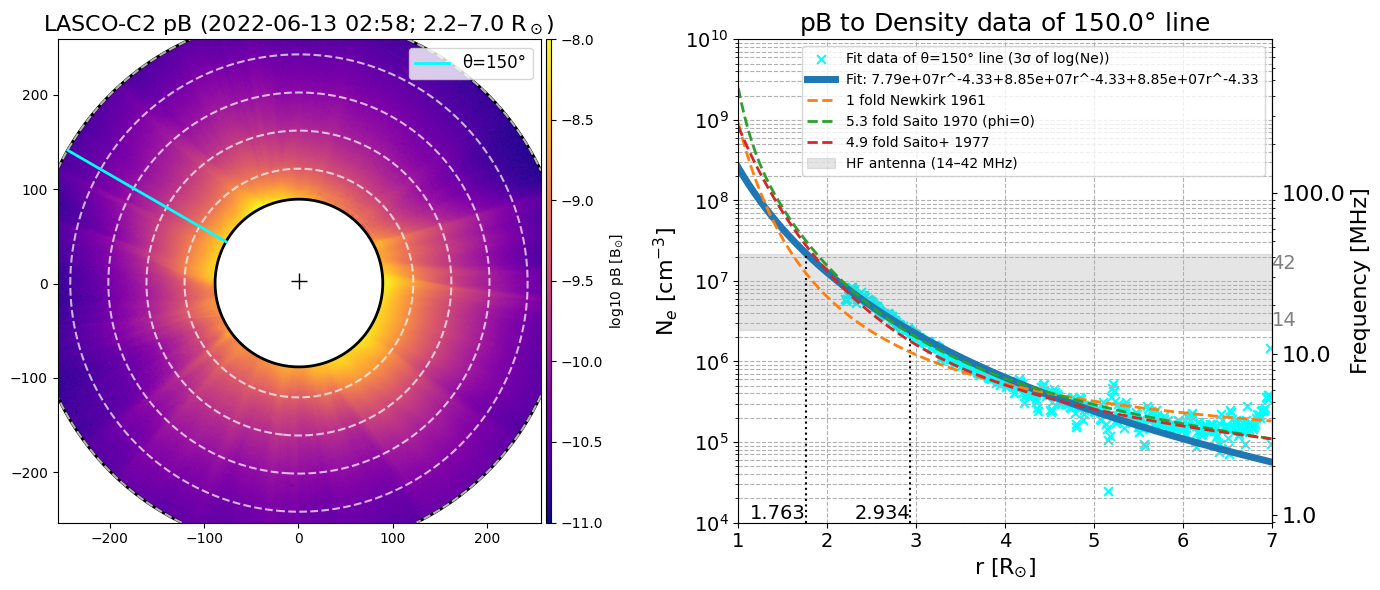

In [5]:
import numpy as np
from pathlib import Path
from astropy.io import fits
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import map_coordinates
from scipy.optimize import curve_fit

# --- （省略）Saito1970, Saito1977, Newkirk1961, f_plasma, rho_at_frequency,
#     triple_power, weight_pB, _K, K_const, R_SUN の定義は元コードのまま ---

# --- 1) FITS 読み込み & プロファイル抽出 ---
# filename = str(Path.home()/'Research'/'SOHO'/'pB'/'C2-PB-20220613_0258.fts')
with fits.open(filename) as hdul:
    pb_data = hdul[0].data.astype(float)
    hdr     = hdul[0].header

cx = hdr['CRPIX1']-1; cy = hdr['CRPIX2']-1
arcsec_per_px   = abs(hdr['CDELT1'])
solar_radius_as = hdr.get('RSUN_OBS', 959.2)
px_per_Rsun     = solar_radius_as/arcsec_per_px

ny, nx = pb_data.shape
y, x   = np.indices((ny,nx))
r_map  = np.hypot((x-cx)/px_per_Rsun, (y-cy)/px_per_Rsun)

# --- 2) 2.2–9.0 R⊙ のビン & pB プロファイル ---
r_min, r_max, dr = 2.2, 7.0, 0.01
edges = np.arange(r_min, r_max+dr, dr)
r_mid = 0.5*(edges[:-1]+edges[1:])
n_bins = len(r_mid)


# --- 3) Onion-peeling Abel 反転で Ne(r_mid) 計算準備 ---
Ne_line = np.zeros(n_bins)

rho0   = r_mid[-1] * R_SUN
tail_b = 3.0
r_out  = rho0 * 1.0001
r_grid = np.linspace(r_out, 10*rho0, 2000)
Wgrid  = weight_pB(r_grid)
geom   = (rho0**2)/(r_grid*np.sqrt(r_grid**2 - rho0**2))
tail_factor = np.trapezoid(Wgrid * geom * (rho0/r_grid)**tail_b, r_grid)

# --- 4) θ=150° の線上 pB プロファイル抽出 & 反転初期化 ---
theta_deg = 150.0
theta_rad = np.radians(theta_deg)
x_line = cx + r_mid*px_per_Rsun * np.cos(theta_rad)
y_line = cy + r_mid*px_per_Rsun * np.sin(theta_rad)
coords = np.vstack([y_line, x_line])
pb_line = map_coordinates(pb_data, coords, order=1, mode='constant', cval=np.nan)

Ne_line[-1] = pb_line[-1] / (K_const * tail_factor)

# --- 葉切り法反転ループ ---
for i in range(n_bins-2, -1, -1):
    rho = r_mid[i] * R_SUN
    pB_rem_line = pb_line[i] / K_const

    for j in range(i+1, n_bins):

        if Ne_line[j] > 0:
            r_in  = max(edges[j],    r_mid[i])   * R_SUN
            r_outj= edges[j+1]       * R_SUN
            L_j   = rho * (
                np.arctan(np.sqrt(r_outj**2 - rho**2)/rho) -
                np.arctan(np.sqrt(max(r_in**2 - rho**2,0))/rho)
            )
            Wj    = weight_pB(r_mid[j]*R_SUN)
            pB_rem_line -= Wj * Ne_line[j] * L_j

    L_i     = rho * np.arctan(np.sqrt((edges[i+1]*R_SUN)**2 - rho**2)/rho)
    Wi      = weight_pB(r_mid[i]*R_SUN)
    Ne_line[i] = pB_rem_line / (Wi*L_i) if Wi*L_i > 0 else 0.0

# --- 5) R>9 R⊙ を NaN に ---
Ne_line[r_mid > r_max] = np.nan

# --- 6) フィッティング範囲マスク & ３σクリッピング ---
# mask_base は従来どおり
mask_base = (
    (r_mid >= r_min) &
    (r_mid <= r_max) &
    np.isfinite(Ne_line)
)

r0  = r_mid[mask_base]
Ne0 = Ne_line[mask_base]

# 対数に変換
logNe = np.log10(Ne0)

# 対数空間で平均・標準偏差
mu_log   = np.nanmean(logNe)
sigma_log= np.nanstd(logNe)

# log-space で 3σ クリップ
mask_log = np.abs(logNe - mu_log) <= 3*sigma_log

# フィット用データ
r_fit  = r0[mask_log]
Ne_fit = Ne0[mask_log]

if len(Ne_fit) < 5:
    raise RuntimeError(f"フィット用データ点が足りません: {len(Ne_fit)} 点")

# 8) フィッティング & 結果表示
p0 = [1.5e7, -3.4, 2.6e7, -3.4, 2.6e7, -3.4]
params, _ = curve_fit(triple_power, r_fit, Ne_fit, p0=p0, maxfev=100000)
A1, p1, A2, p2, A3, p3 = params

print("Line data fit results:")
print(f" A1={A1:.2e}, p1={p1:.2f}")
print(f" A2={A2:.2e}, p2={p2:.2f}")
print(f" A3={A3:.2e}, p3={p3:.2f}")

# --- 8) プロット ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6), tight_layout=True)

# (a) pB 画像 + 等高円 + θ線
# (a) pB 画像
plot_pb = np.log10(pb_data.copy())
plot_pb[(r_map<r_min)|(r_map>r_max)] = np.nan
xmin, xmax = -cx, nx-cx
ymin, ymax = -cy, ny-cy
im = ax1.imshow(plot_pb, origin='lower', cmap='plasma',
                vmin=-11, vmax=-8,
                extent=[xmin,xmax,ymin,ymax], aspect='equal')

# 元の r_min, r_max の輪郭
ax1.contour(r_map, levels=[r_min, 7], colors='black', linewidths=2,
            extent=[xmin,xmax,ymin,ymax])
# 等高円
int_lv = np.arange(1, int(np.floor(r_max))+1)
ax1.contour(r_map, levels=int_lv, colors='white', linestyles='--',
            extent=[xmin,xmax,ymin,ymax], alpha=0.7)
# 中心点
ax1.plot((xmax+xmin)/2, (ymax+ymin)/2, '+', color='black', markersize=12)


# θ=150° の直線（イメージ内に収まる点だけプロット）
r_line = np.linspace(r_min, r_max, 400)
x_plot = r_line * px_per_Rsun * np.cos(theta_rad)
y_plot = r_line * px_per_Rsun * np.sin(theta_rad)
# イメージ表示範囲内の点を選択
mask_inside = (x_plot >= xmin) & (x_plot <= xmax) & (y_plot >= ymin) & (y_plot <= ymax)
ax1.plot(x_plot[mask_inside], y_plot[mask_inside],
         c='cyan', lw=2, label=f'θ={theta_deg:.0f}°')
ax1.legend(loc='upper right', fontsize=12)

# カラーバー等の仕上げ
cax = make_axes_locatable(ax1).append_axes("right", size="1%", pad=0.05)
plt.colorbar(im, cax=cax, label='log10 pB [B$_⊙$]')
# ax1.set_xlabel('X [pix]', fontsize=14); ax1.set_ylabel('Y [pix]', fontsize=14)
ax1.set_title(f'LASCO-C2 pB (2022-06-13 02:58; {r_min:.1f}–{r_max:.1f} R$_\\odot$)', fontsize=16)



# ------------------------------------
# (b) Ne プロファイル（Scatter + Fit Curve）
r_curve = np.linspace(1.0, r_max, 500)
# ax2.scatter(r_mid, Ne_line, s=20, c='gray', marker='o', label=f'θ={theta_deg:.0f}° line')
ax2.scatter(r_fit,  Ne_fit,  s=40, c='cyan', marker='x', label=f'Fit data of θ={theta_deg:.0f}° line (3σ of log(Ne))')
r_curve = np.linspace(1, r_max, 500)
ax2.plot(r_curve, triple_power(r_curve, *params),
         '-', label=f'Fit: {A1:.2e}r^{p1:.2f}+{A2:.2e}r^{p2:.2f}+{A3:.2e}r^{p3:.2f}', linewidth=5)

# 14MHzと42MHzに対応する密度からrを求める
def find_r_from_density(target_density, r_range, params):
    r_values = np.linspace(r_range[0], r_range[1], 1000)
    densities = triple_power(r_values, *params)
    # 密度の差が最小となるrを探す
    idx = np.argmin(np.abs(densities - target_density))
    return r_values[idx]

r_14MHz = find_r_from_density(density_from_frequency(14), (1, r_max), params)
r_42MHz = find_r_from_density(density_from_frequency(42), (1, r_max), params)

print(f"14MHz (Ne={density_from_frequency(14):.2e} cm^-3) に対応する r = {r_14MHz:.2f} R_sun")
print(f"42MHz (Ne={density_from_frequency(42):.2e} cm^-3) に対応する r = {r_42MHz:.2f} R_sun")
density_min, density_max = 1e4, 1e10


# プロットに縦線を追加
ax2.vlines(r_14MHz, density_min, density_from_frequency(14), color='black', linestyle=':')
ax2.vlines(r_42MHz, density_min, density_from_frequency(42), color='black', linestyle=':')
ax2.text(r_14MHz, density_min, f'{r_14MHz:.3f}', ha='right', va='bottom', color='black', fontsize=14)
ax2.text(r_42MHz, density_min, f'{r_42MHz:.3f}', ha='right', va='bottom', color='black', fontsize=14)



Newkirk_C = 1
Saito1970_C = 5.3
Saito1977_C = 4.9

ax2.plot(r_curve, Newkirk_C * Newkirk1961(r_curve), label=f'{Newkirk_C} fold Newkirk 1961', linestyle='--', linewidth=2)
ax2.plot(r_curve, Saito1970_C * Saito1970(r_curve, phi=0), label=f'{Saito1970_C} fold Saito 1970 (phi=0)', linestyle='--', linewidth=2)
ax2.plot(r_curve, Saito1977_C * Saito1977(r_curve), label=f'{Saito1977_C} fold Saito+ 1977', linestyle='--', linewidth=2)

ax2.axhspan(density_from_frequency(14), density_from_frequency(42), color='gray', alpha=0.2,
           label='HF antenna (14–42 MHz)')
ax2.text(r_max, density_from_frequency(14), '14', va='bottom', ha='left', fontsize=14, color='gray')
ax2.text(r_max, density_from_frequency(42), '42', va='top', ha='left', fontsize=14, color='gray')

ax2.set_yscale('log')
ax2.set_xlim(1, 7)
ax2.set_ylim(density_min, density_max)
ax2.set_xlabel('r [R$_⊙$]', fontsize=16); ax2.set_ylabel('N$_e$ [cm$^{-3}$]', fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.grid(which='both', ls='--'); ax2.legend()
ax2.set_title(f'pB to Density data of {theta_deg}$\degree$ line', fontsize=18)

secax = ax2.secondary_yaxis(
        'right',
        functions=(frequency_from_density, density_from_frequency)
    )
secax.set_ylabel('Frequency [MHz]', fontsize=16)
secax.set_yscale('log')
secax.yaxis.set_major_locator(LogLocator(base=10))
secax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))
secax.tick_params(axis='both', which='major', labelsize=16)

plt.show()


C:\Users\touho\AppData\Local\Temp\ipykernel_7288\1424883342.py:39: RuntimeWarning: overflow encountered in power
  return A1*r**p1 + A2*r**p2 + A3*r**p3
C:\Users\touho\AppData\Local\Temp\ipykernel_7288\1424883342.py:39: RuntimeWarning: invalid value encountered in add
  return A1*r**p1 + A2*r**p2 + A3*r**p3


14MHz (Ne=2.43e+06 cm^-3) に対応する r = 5.42 R_sun
42MHz (Ne=2.19e+07 cm^-3) に対応する r = 2.45 R_sun


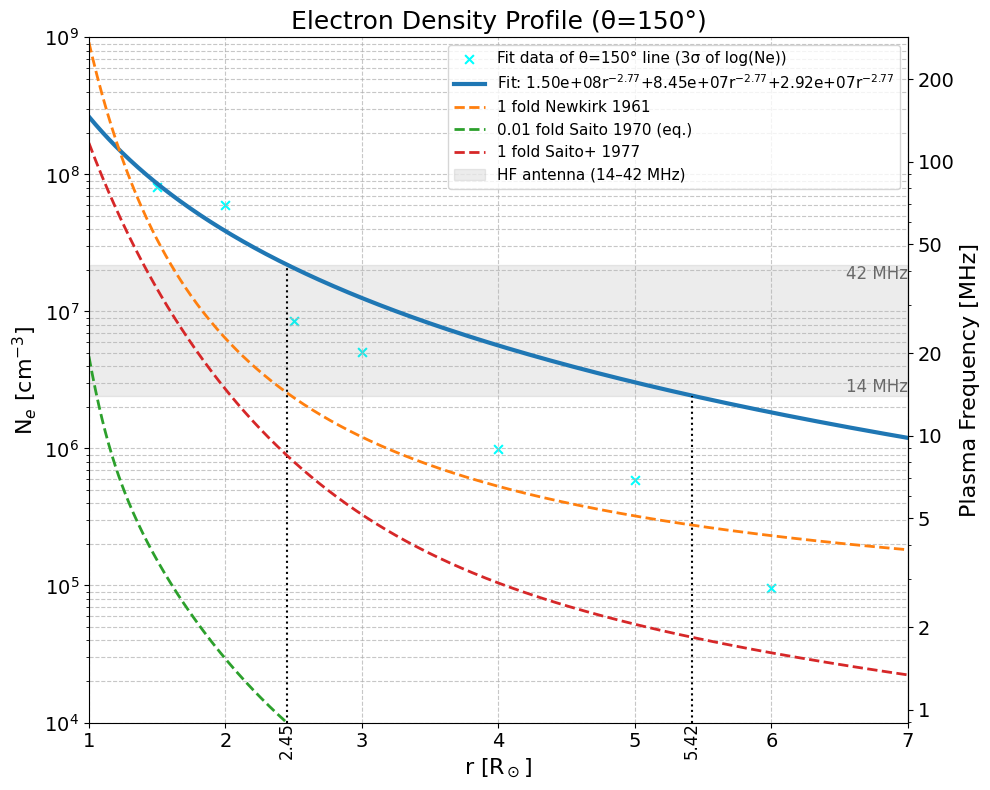

In [6]:
# ダミーの入力データ
fig, ax2 = plt.subplots(figsize=(10, 8)) # ax2 を作成
r_max_example = 7.0
r_min_example = 1.0

# フィットデータ (ダミー)
r_fit_example = np.array([1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0])
# Ne_fit_example = triple_power(r_fit_example, 1.5e7, -3.4, 2.6e7, -5.0, 2.6e6, -2.0) * (0.8 + 0.4*np.random.rand(len(r_fit_example)))
Ne_fit_example = np.array([1e8, 5e7, 1e7, 5e6, 1e6, 5e5, 1e5]) * (0.8 + 0.4*np.random.rand(len(r_fit_example)))


# フィットパラメータ (ダミー)
# params_example = (1.5e7, -3.4, 2.6e7, -5.0, 2.6e6, -2.0)
# 実際の値に近いように調整
try:
    from scipy.optimize import curve_fit
    params_example, _ = curve_fit(triple_power, r_fit_example, Ne_fit_example, p0=[1e8, -2, 1e7, -4, 1e6, -6], maxfev=50000)
except:
    print("curve_fit failed with dummy data, using arbitrary params_example")
    params_example = (4e7, -2.5, 1e7, -4.0, 1e5, -1.5)


theta_deg_example = 150.0
density_min_example, density_max_example = 1e4, 1e9 # Y軸範囲調整

model_multipliers_example = {
    'Newkirk_C': 1, 
    'Saito1970_C': 0.01, # Saito1970 is often much higher, scale for plot
    'Saito1977_C': 1
}

# --- メインの描画関数呼び出し ---
generate_ne_profile_plot(ax=ax2, 
                            r_fit_data=r_fit_example, 
                            Ne_fit_data=Ne_fit_example, 
                            fit_params_tuple=params_example, 
                            plot_r_min=r_min_example,
                            plot_r_max=r_max_example, 
                            theta_deg_val=theta_deg_example, 
                            density_plot_limits=(density_min_example, density_max_example), 
                            model_multipliers_dict=model_multipliers_example)

plt.tight_layout() # 最後に呼び出す
plt.show()

# Mk4

## plot

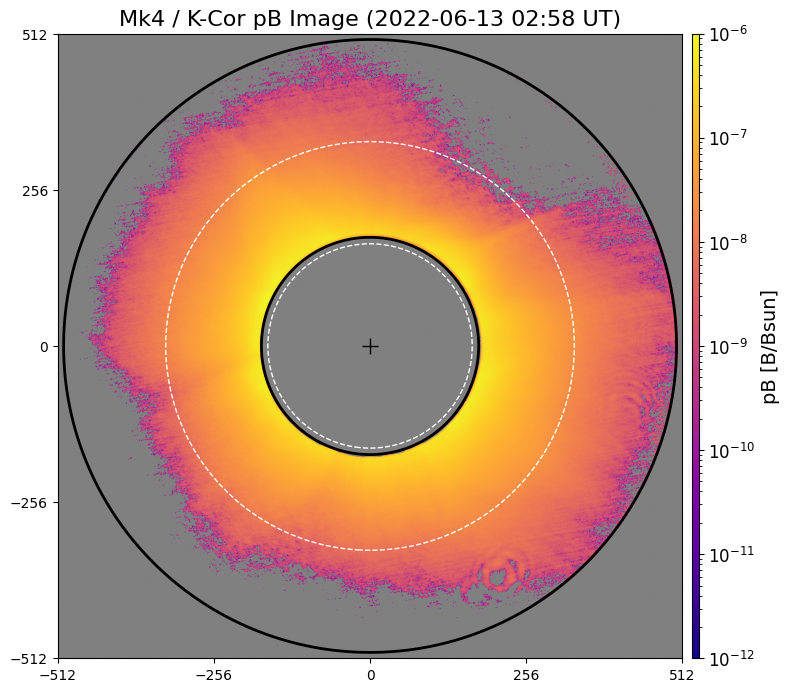

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- すでに取得してある前処理情報 -----------------------------
# data           : 2D pB 配列（ny × nx）
# cx, cy         : FITS の Sun-center ピクセル (0-index)
# pixel_scale_arc: 1 px あたりの角度 [arcsec]
# rsun_arc       : 1 R⊙ に相当する角度 [arcsec]


# -------------------------------------------------
# 1) Sun-center を (0,0) とするピクセル座標グリッド
ny, nx = data.shape
x_pix = np.arange(nx) - cx
y_pix = np.arange(ny) - cy            # origin='lower' に合わせる
xmin, xmax = -cx, nx - cx
ymin, ymax = -cy, ny - cy
xx, yy = np.meshgrid(x_pix, y_pix)

# 2) ピクセル半径 → R⊙ 単位
r_rsun = np.sqrt(xx**2 + yy**2) * pixel_scale_arc / rsun_arc
r_map  = r_rsun                        # ↓ contour 用にそのまま使う

# 3) 遮蔽板 (例: 1.07 R⊙) 以内をマスク灰色化
# --- ヘッダーから数値を取得 ---
solar_radius_px  = header['R_SUN']              # 167.46
occulter_px = header.get('RCAM_DCR',            # 178.07
               header.get('TCAM_DCR',
               header.get('RCAM_RAD')))         # フォールバック

mask_radius_rsun = occulter_px / solar_radius_px  # ≈ 1.063

# # --- 1.07 R⊙ 以内をマスク ---
# mask = r_rsun <= (mask_radius_rsun + 0.01)  # +0.01 R⊙ ほど余裕
# masked_data = np.ma.masked_where(mask, data)



# 4) “bad” を灰色にしたカラーマップ
cmap = plt.cm.plasma.copy()
cmap.set_bad(color='gray')

# 5) プロット ----------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

extent = [x_pix.min(), x_pix.max(), y_pix.min(), y_pix.max()]

im = ax.imshow(
    data,
    origin='lower',
    cmap=cmap,
    norm=LogNorm(vmin=1e-12, vmax=1e-6),
    extent=extent,
    aspect='equal'
)

# --- 輪郭線と整数 R⊙ 点線円 -------------------------
# 元の解析範囲 (r_min, r_max-1) の太線
ax.contour(
    r_map,
    levels=[mask_radius_rsun, 3.0],
    colors='black',
    linewidths=2,
    extent=extent
)

# 整数 R⊙ ごとの点線円
int_levels = np.arange(1, 3)   # 1,2,3,...
ax.contour(
    r_map,
    levels=int_levels,
    colors='white',
    linewidths=1,
    linestyles='--',
    extent=extent
)

# 中心位置
ax.plot((xmax+xmin)/2, (ymax+ymin)/2, '+', color='black', markersize=12)
# カラーバー
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('pB [B/Bsun]', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# タイトル等
ax.set_title('Mk4 / K-Cor pB Image (2022-06-13 02:58 UT)', fontsize=16)
tick_vals = np.linspace(-nx/2, nx/2, 5, dtype=int)
ax.set_xticks(tick_vals)
ax.set_yticks(tick_vals)

plt.tight_layout()
plt.show()


Successfully loaded Mk4 file: D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\pB\20220613_025810_kcor_l2.fts
Mk4 params: cx=511.50, cy=511.50, scale=5.643 arcsec/px, rsun=944.95 arcsec, R_sun_px=167.46 px
Successfully loaded SOHO/LASCO file: D:\wsl\home\kinno-7010\Research\SOHO\pB\C2-PB-20220613_0258.fts
SOHO/LASCO params: cx=255.10, cy=253.25, scale=23.800 arcsec/px, rsun=959.20 arcsec, R_sun_px=40.30 px


C:\Users\touho\AppData\Local\Temp\ipykernel_18764\3226748284.py:41: RuntimeWarning: overflow encountered in power
  return A1*r**p1 + A2*r**p2 + A3*r**p3 + A4*r**p4 + A5*r**p5
C:\Users\touho\AppData\Local\Temp\ipykernel_18764\3226748284.py:41: RuntimeWarning: invalid value encountered in add
  return A1*r**p1 + A2*r**p2 + A3*r**p3 + A4*r**p4 + A5*r**p5
C:\Users\touho\AppData\Local\Temp\ipykernel_18764\3226748284.py:41: RuntimeWarning: overflow encountered in multiply
  return A1*r**p1 + A2*r**p2 + A3*r**p3 + A4*r**p4 + A5*r**p5


14MHz (Ne=2.43e+06 cm^-3) に対応する r = 3.25 R_sun
42MHz (Ne=2.19e+07 cm^-3) に対応する r = 1.99 R_sun


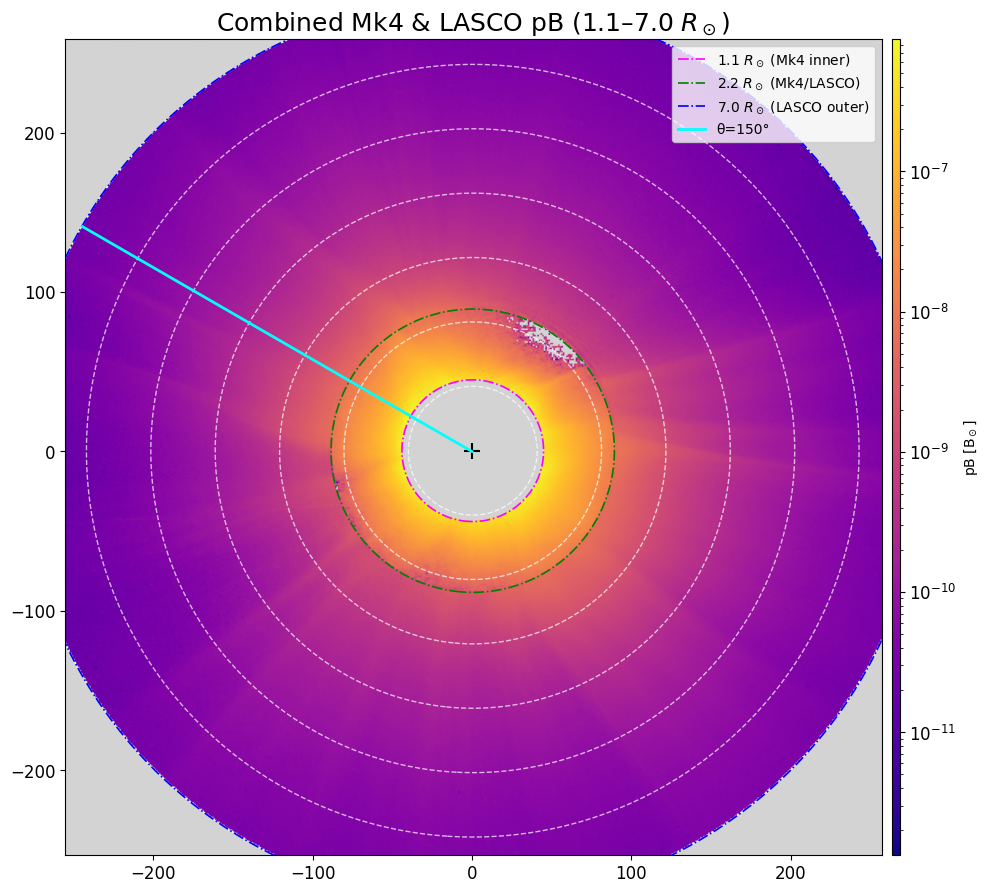

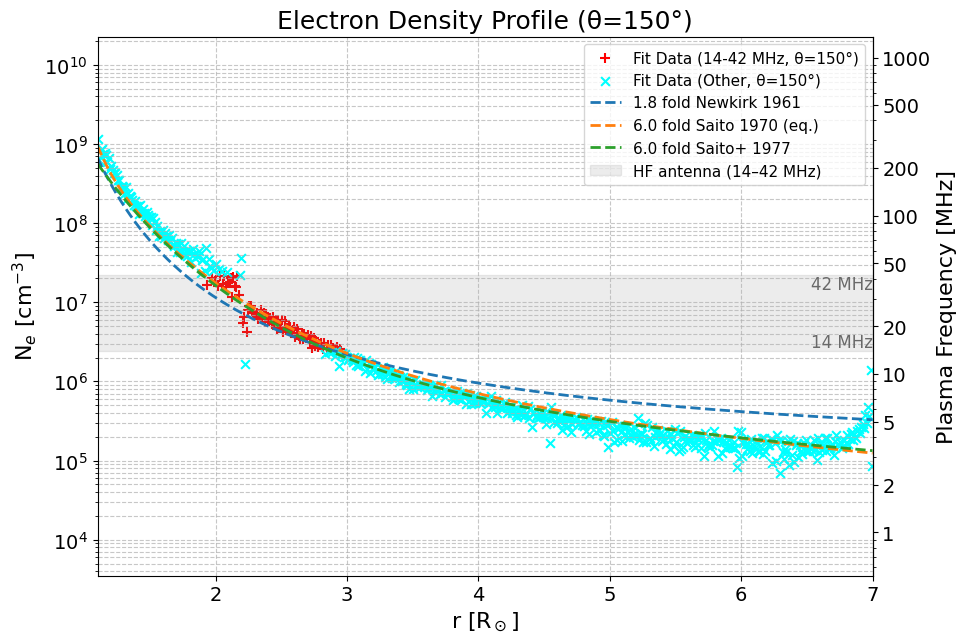

In [7]:
data_mk4, params_mk4 = load_and_prepare_instrument_data(filename_mk4, "Mk4")
data_lasco, params_lasco = load_and_prepare_instrument_data(filename_lasco, "SOHO/LASCO", is_lasco=True)

final_image, r_map_lasco, theta_to_plot = None, None, 150.0
r_ranges = {'mk4_inner': 1.1, 'mk4_outer_lasco_inner': 2.2, 'lasco_outer': 7.0}

if params_lasco and data_lasco is not None : # Ensure LASCO data is primary reference for grid
    _y, _x = np.indices((params_lasco['ny'], params_lasco['nx']))
    r_map_lasco = np.hypot((_x - params_lasco['cx']) / params_lasco['px_per_rsun'],
                            (_y - params_lasco['cy']) / params_lasco['px_per_rsun'])
    if params_mk4 and data_mk4 is not None:
            final_image = combine_corona_data(data_lasco, params_lasco, data_mk4, params_mk4, r_map_lasco, r_ranges)
    else: # Use LASCO only if MK4 fails
        print("Warning: MK4 data/params failed to load. Using LASCO data only for 'final_image'.")
        final_image = data_lasco.copy() # Make a copy
        # Mask final_image based on lasco_outer and a reasonable inner bound if mk4_inner not applicable
        final_image[r_map_lasco > r_ranges['lasco_outer']] = np.nan
        # Define a minimum r if only LASCO is used, e.g., LASCO's typical inner edge
        lasco_effective_inner = r_ranges.get('mk4_outer_lasco_inner', 2.0) # Default if key missing
        final_image[r_map_lasco < lasco_effective_inner ] = np.nan


    if final_image is not None:
        plot_combined_image(final_image, r_map_lasco, params_lasco, r_ranges, theta_deg_overlay=theta_to_plot)
else:
    print("Critical: LASCO data/params failed to load. Cannot proceed with image processing.")
    exit()


bin_width = 0.01
current_plot_r_min = r_ranges.get('mk4_inner',1.1) # Use .get for safety
current_plot_r_max = r_ranges.get('lasco_outer',7.0)
edges = np.arange(current_plot_r_min, current_plot_r_max + bin_width, bin_width)
r_mid = (edges[:-1] + edges[1:]) / 2 if len(edges) > 1 else np.array([])
n_bins = len(r_mid)

pB_line = np.full_like(r_mid, np.nan)
if final_image is not None and r_map_lasco is not None and params_lasco and n_bins > 0 :
    pB_line = extract_pB_profile(final_image, r_map_lasco, theta_to_plot, edges,
                                    params_lasco['cy'], params_lasco['cx'],
                                    params_lasco['ny'], params_lasco['nx'])

Ne_line = np.full_like(pB_line, np.nan)
if not np.all(np.isnan(pB_line)) and n_bins > 0:
    Ne_line = invert_ablation(pB_line, r_mid, edges, n_bins) # Re-assign

valid_ne_indices = ~np.isnan(Ne_line) & (Ne_line > 1e-9)
r_all_valid_ne = r_mid[valid_ne_indices]
Ne_all_valid = Ne_line[valid_ne_indices]

fit_r_min = current_plot_r_min
fit_r_max_limit_inclusive = current_plot_r_max + 1.0

fitting_mask = (r_all_valid_ne >= fit_r_min) & (r_all_valid_ne <= fit_r_max_limit_inclusive)
r_for_fitting = r_all_valid_ne[fitting_mask]
Ne_for_fitting = Ne_all_valid[fitting_mask]

# ★★★ Calculate density bounds for highlighting (14-42 MHz) ★★★
ne_14MHz_limit = density_from_frequency(14)
ne_42MHz_limit = density_from_frequency(42)
# Ensure they are ordered correctly and handle potential NaNs
density_lower_highlight = np.nanmin([ne_14MHz_limit, ne_42MHz_limit])
density_upper_highlight = np.nanmax([ne_14MHz_limit, ne_42MHz_limit])
# ★★★ Calculation done ★★★

initial_guess = [1e8, -2, 1e7, -4, 1e6, -6, 1e5, -8, 1e4, -10]
fit_params = tuple(initial_guess)
try:
    if len(r_for_fitting) >= len(initial_guess):
        popt, _ = curve_fit(triple_power, r_for_fitting, Ne_for_fitting, p0=initial_guess, maxfev=300000)
        fit_params = tuple(popt)
    elif len(r_for_fitting) > 0:
            print(f"Warning: Not enough data for robust fitting ({len(r_for_fitting)} points, need {len(initial_guess)}). Fit may be unreliable or based on initial guess.")
except Exception as e: print(f"Fitting error: {e}. Using initial guess.")


fig_ne, ax_ne = plt.subplots(figsize=(10, 7))
density_plot_min_val, density_plot_max_val = 1e3, 1e8

r_curve_for_plot_limits = np.linspace(current_plot_r_min, current_plot_r_max, 200) if current_plot_r_min < current_plot_r_max else np.array([current_plot_r_min])
ne_on_curve_for_plot_limits = np.full_like(r_curve_for_plot_limits, np.nan)
if len(fit_params) == 10 and len(r_curve_for_plot_limits) > 0: 
    ne_on_curve_for_plot_limits = triple_power(r_curve_for_plot_limits, *fit_params)

y_values_to_consider = []
if len(Ne_for_fitting) > 0: y_values_to_consider.extend(Ne_for_fitting[Ne_for_fitting > 0])
# No separate Ne_highlight_data; Ne_for_fitting points are colored based on density.
if np.any(np.isfinite(ne_on_curve_for_plot_limits)):
        y_values_to_consider.extend(ne_on_curve_for_plot_limits[ (ne_on_curve_for_plot_limits > 0) & np.isfinite(ne_on_curve_for_plot_limits)])

if len(y_values_to_consider) > 0:
    y_finite = [y for y in y_values_to_consider if np.isfinite(y) and y > 1e-9]
    if len(y_finite) > 0:
        density_plot_min_val = np.min(y_finite) * 0.05
        density_plot_max_val = np.max(y_finite) * 20
if density_plot_min_val <= 0: density_plot_min_val = 1e1
if density_plot_max_val <= density_plot_min_val: density_plot_max_val = density_plot_min_val * 1000




generate_ne_profile_plot(
    ax_ne,                            # to ax
    r_for_fitting,                    # to r_fit_data_points
    Ne_for_fitting,                   # to Ne_fit_data_points
    fit_params,                       # to fit_params_tuple
    current_plot_r_min,               # to plot_r_min (now correctly a float)
    current_plot_r_max,               # to plot_r_max (now correctly a float)
    theta_to_plot,                    # to theta_deg_val
    (density_plot_min_val, density_plot_max_val), # to density_plot_limits
    {'Newkirk_C': 1.8, 'Saito1970_C': 6.0, 'Saito1977_C': 6.0}, # to model_multipliers_dict
    density_lower_highlight,          # to density_lower_highlight_bound
    density_upper_highlight           # to density_upper_highlight_bound
)
plt.show()